In [1]:
# Imports
import jax
import jax.random as jr
import jax.numpy as jnp
import matplotlib.pyplot as plt
from diffrax import *

In [124]:
# Global default parameters
t0, t1 = 0, 10
epsilon = 0.001
lag = 1.2*epsilon
solver_epsilon = 0.01*epsilon
times = jnp.arange(t0, t1, epsilon)

In [119]:
# Optionally override default parameters
# t0, t1 = 0, 10
# epsilon = 0.001
# lag = epsilon
# solver_epsilon = 0.01*epsilon
# times = jnp.arange(t0, t1, epsilon)

In [3]:

def fun_to_array(grid, fun):
    return jax.vmap(lambda t: fun(t))(grid)
new_times = jnp.arange(1, 2, epsilon)

def lagged_control(fun, lag):
    return lambda s,t: fun(jnp.maximum(0,t - lag/2)) - fun(jnp.maximum(0,s - lag/2))

def join_controls(lagged, original):
    return lambda s,t: jnp.concatenate((lagged(s,t), original(s,t)))




We want to approximate the solution to $\mathrm{d}Y_t = \sigma(Y_t,t) \mathrm{d} W_t$ as $\dot Y^{\varepsilon, +}$, where $$\begin{pmatrix} \dot Y^{\varepsilon, -}_t \\ \dot Y^{\varepsilon, +}_t \end{pmatrix} =  \sigma(Y^{\varepsilon, -}_t) \begin{pmatrix} \dot W^{\varepsilon, -}_t \\ \dot W^{\varepsilon, +}_t \end{pmatrix}.$$ Here $\varepsilon$ is the discretisation of the brownian motion; the solver should be on a finer grid.

In [137]:
# Generate a Brownian motion
vbt = VirtualBrownianTree(t0, t1+2*epsilon, tol=epsilon, shape=(1,), key=jr.PRNGKey(507))
bm_control = vbt.evaluate
lagged_bm_control = lagged_control(bm_control, lag)
lead_lag_control = join_controls(lagged_bm_control, bm_control)



In [159]:
# Stochastic exponential

y0 = jnp.array([1, 1])
drift = lambda t, y, args: jnp.array([0, 0])
diffusion = lambda t, y, args: jnp.array([[y[0], 0], [0, y[0]]])
terms = MultiTerm(ODETerm(drift), ControlTerm(diffusion, lead_lag_control))
ODE_solver = Midpoint() # if this is an Ito solver, the first coordinate will not converge to Stratonovich
saveat = SaveAt(ts = times)
lead_lag_sol = diffeqsolve(terms, ODE_solver, t0, t1, dt0 = solver_epsilon, max_steps = None, y0 = y0, saveat=saveat)

def ito_sol_true(bm):
    return lambda t: jnp.exp(bm(t) - t/2)

def strat_sol_true(bm):
    return lambda t: jnp.exp(bm(t))

ito_true_array = fun_to_array(times, ito_sol_true(bm_control))
strat_true_array = fun_to_array(times, strat_sol_true(bm_control))


In [160]:
y0 = jnp.array([1])
drift_ito = lambda t, y, args: jnp.array([0])
diffusion_ito = lambda t, y, args: jnp.array([y[0]])
terms = MultiTerm(ODETerm(drift_ito), ControlTerm(diffusion_ito, bm_control))
ito_solver = Euler()
saveat = SaveAt(ts = times)
ito_sol = diffeqsolve(terms, ito_solver, t0, t1, dt0 = epsilon, max_steps = None, y0 = y0, saveat=saveat)

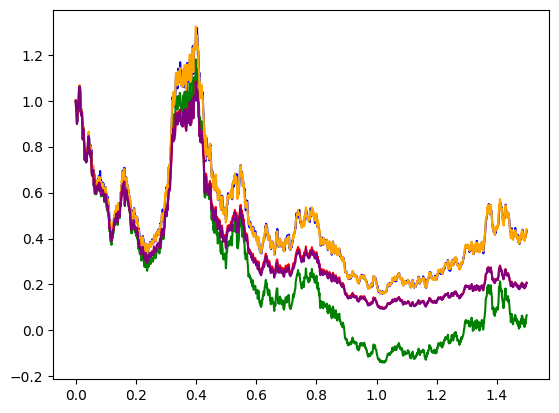

In [149]:
a, b = 0, 1500
plt.plot(lead_lag_sol.ts[a : b], lead_lag_sol.ys[a : b,0], color = "blue") # lead-lag Strat
plt.plot(lead_lag_sol.ts[a : b], lead_lag_sol.ys[a : b,1], color = "green") # lead-lag Ito
plt.plot(times[a : b], strat_true_array[a : b], color = "orange") # true Strat
plt.plot(times[a : b], ito_true_array[a : b], color = "red") # true Ito
plt.plot(ito_sol.ts[a : b], ito_sol.ys[a : b, 1], color = "purple") # Ito with Euler/Milstein solver

# Doesn't converge

In [152]:
# Integral of BdB = B^2/2

y0 = jnp.array([0, 0, 0])
drift = lambda t, y, args: jnp.array([0, 0, 0])
diffusion = lambda t, y, args: jnp.array([[1, 0], [y[0], 0], [0, y[0]]])
terms = MultiTerm(ODETerm(drift), ControlTerm(diffusion, lead_lag_control))
strat_solver = Euler()
saveat = SaveAt(ts = times)
lead_lag_sol = diffeqsolve(terms, strat_solver, t0, t1, dt0 = solver_epsilon, max_steps = None, y0 = y0, saveat=saveat)

def ito_sol_true(bm):
    return lambda t: jnp.square(bm(t))/2 - t/2

def strat_sol_true(bm):
    return lambda t: jnp.square(bm(t))/2

ito_true_array = fun_to_array(times, ito_sol_true(bm_control))
strat_true_array = fun_to_array(times, strat_sol_true(bm_control))

In [153]:
y0 = jnp.array([0, 0])
drift_ito = lambda t, y, args: jnp.array([0, 0])
diffusion_ito = lambda t, y, args: jnp.array([[1], [y[0]]])
terms = MultiTerm(ODETerm(drift_ito), ControlTerm(diffusion_ito, bm_control))
ito_solver = Euler()
saveat = SaveAt(ts = times)
ito_sol = diffeqsolve(terms, strat_solver, t0, t1, dt0 = epsilon, max_steps = None, y0 = y0, saveat=saveat)

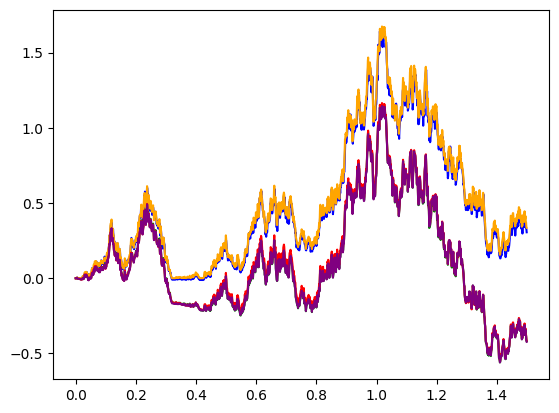

In [154]:
a, b = 0, 1500
plt.plot(lead_lag_sol.ts[a : b], lead_lag_sol.ys[a : b, 1], color = "blue") # lead-lag Strat
plt.plot(lead_lag_sol.ts[a : b], lead_lag_sol.ys[a : b, 2], color = "green") # lead-lag Ito
plt.plot(times[a : b], strat_true_array[a : b], color = "orange") # true Strat
plt.plot(times[a : b], ito_true_array[a : b], color = "red") # true Ito
plt.plot(ito_sol.ts[a : b], ito_sol.ys[a : b, 1], color = "purple") # Ito with Euler/Milstein solver

# It converges!

In [256]:
# dY = cos(Y)dB

y0 = jnp.array([1, 1])
drift = lambda t, y, args: jnp.array([0, 0])
diffusion = lambda t, y, args: jnp.array([[jnp.cos(y[0]), 0], [0, jnp.cos(y[0])]])
terms = MultiTerm(ODETerm(drift), ControlTerm(diffusion, lead_lag_control))
ODE_solver = Midpoint() # if this is an Ito solver, the first coordinate will not converge to Stratonovich
saveat = SaveAt(ts = times)
lead_lag_sol_sin = diffeqsolve(terms, ODE_solver, t0, t1, dt0 = solver_epsilon, max_steps = None, y0 = y0, saveat=saveat)


y0 = jnp.array([1])
drift_ito = lambda t, y, args: jnp.array([0])
diffusion_ito = lambda t, y, args: jnp.array([jnp.cos(y[0])])
terms = MultiTerm(ODETerm(drift_ito), ControlTerm(diffusion_ito, bm_control))
ito_solver = Euler()
saveat = SaveAt(ts = times)
ito_sol_sin = diffeqsolve(terms, ito_solver, t0, t1, dt0 = epsilon, max_steps = None, y0 = y0, saveat=saveat)

y0 = jnp.array([1])
drift_strat = lambda t, y, args: jnp.array([0])
diffusion_strat = lambda t, y, args: jnp.array([jnp.cos(y[0])])
terms = MultiTerm(ODETerm(drift_strat), ControlTerm(diffusion_strat, bm_control))
strat_solver = Midpoint()
saveat = SaveAt(ts = times)
strat_sol_sin = diffeqsolve(terms, strat_solver, t0, t1, dt0 = epsilon, max_steps = None, y0 = y0, saveat=saveat)


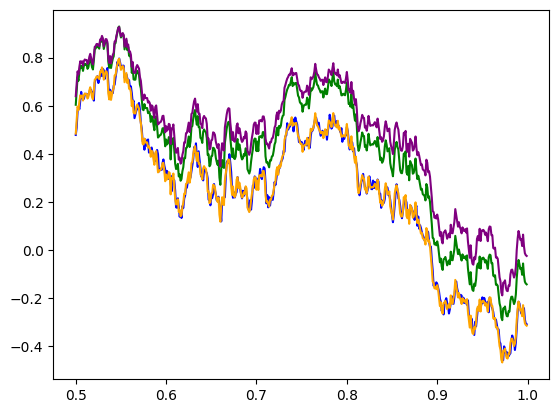

In [257]:
a, b = 500, 1000
plt.plot(lead_lag_sol_sin.ts[a : b], lead_lag_sol_sin.ys[a : b,0], color = "blue") # lead-lag Strat
plt.plot(lead_lag_sol_sin.ts[a : b], lead_lag_sol_sin.ys[a : b,1], color = "green") # lead-lag Ito
plt.plot(ito_sol_sin.ts[a : b], ito_sol_sin.ys[a : b, 1], color = "purple") # Ito with Euler/Milstein solver
plt.plot(strat_sol_sin.ts[a : b], strat_sol_sin.ys[a : b, 1], color = "orange") # Strat with midpoint solver

# Doesn't converge... is this a theory issue?

Now let's try $$ \mathrm{d}Y = \sin(Y) \mathrm{d}W^- + \cos(Y) \mathrm{d}W $$ which should coincide with $$\mathrm{d}Y = (\sin(Y) + \cos(Y)) \circ \mathrm{d}W + \frac 12 \mathrm{d}t $$

In [231]:
# dY = sin(Y)dW^- + cos(Y)dW

y0 = jnp.array([1])
drift = lambda t, y, args: jnp.array([0])
diffusion = lambda t, y, args: jnp.array([[jnp.sin(y[0]), jnp.cos(y[0])]])
terms = MultiTerm(ODETerm(drift), ControlTerm(diffusion, lead_lag_control))
ODE_solver = Midpoint()
saveat = SaveAt(ts = times)
lead_lag_sol_sum = diffeqsolve(terms, ODE_solver, t0, t1, dt0 = solver_epsilon, max_steps = None, y0 = y0, saveat=saveat)

y0 = jnp.array([1])
drift_strat = lambda t, y, args: jnp.array([1/2])
diffusion_strat = lambda t, y, args: jnp.array([jnp.sin(y[0]) + jnp.cos(y[0])])
terms = MultiTerm(ODETerm(drift_strat), ControlTerm(diffusion_strat, bm_control))
strat_solver = Midpoint()
saveat = SaveAt(ts = times)
strat_sol_sum = diffeqsolve(terms, strat_solver, t0, t1, dt0 = epsilon, max_steps = None, y0 = y0, saveat=saveat)


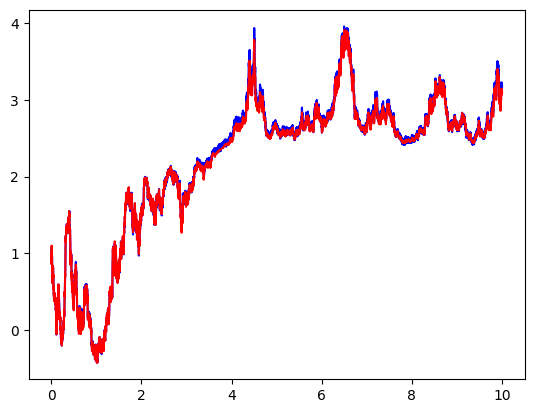

In [232]:
a, b = 0, 10000
plt.plot(lead_lag_sol_sum.ts[a : b], lead_lag_sol_sum.ys[a : b,0], color = "blue") # lead-lag Strat
plt.plot(strat_sol_sum.ts[a : b], strat_sol_sum.ys[a : b,0], color = "red") # Strat with Lie bracket

# It converges!


In [270]:
# dY = sin(Y)dW^- + YdW

y0 = jnp.array([1])
drift = lambda t, y, args: jnp.array([0])
diffusion = lambda t, y, args: jnp.array([[jnp.sin(y[0]), y[0]]])
terms = MultiTerm(ODETerm(drift), ControlTerm(diffusion, lead_lag_control))
ODE_solver = Midpoint()
saveat = SaveAt(ts = times)
lead_lag_sol_sum = diffeqsolve(terms, ODE_solver, t0, t1, dt0 = solver_epsilon, max_steps = None, y0 = y0, saveat=saveat)

y0 = jnp.array([1])
drift_strat = lambda t, y, args: jnp.array([(y[0]*jnp.cos(y[0])-jnp.sin(y[0]))/2])
diffusion_strat = lambda t, y, args: jnp.array([jnp.sin(y[0]) + y[0]])
terms = MultiTerm(ODETerm(drift_strat), ControlTerm(diffusion_strat, bm_control))
strat_solver = Midpoint()
saveat = SaveAt(ts = times)
strat_sol_sum = diffeqsolve(terms, strat_solver, t0, t1, dt0 = epsilon, max_steps = None, y0 = y0, saveat=saveat)


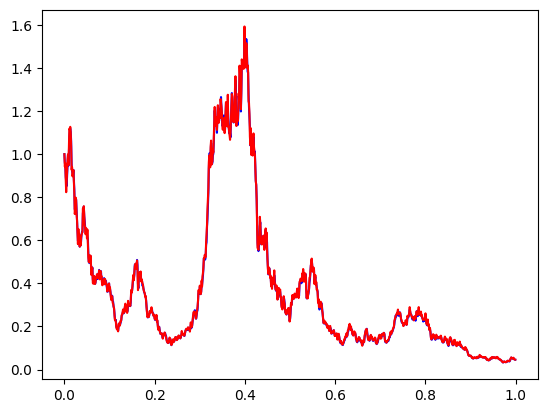

In [271]:
a, b = 0, 1000
plt.plot(lead_lag_sol_sum.ts[a : b], lead_lag_sol_sum.ys[a : b,0], color = "blue") # lead-lag Strat
plt.plot(strat_sol_sum.ts[a : b], strat_sol_sum.ys[a : b,0], color = "red") # Strat with Lie bracket

# It converges!